In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

from src.hybrid_pipeline import HybridFraudPipeline

In [5]:
df = pd.read_csv("../data/raw/creditcard.csv")
X = df.drop("Class", axis=1)
y = df["Class"]

In [6]:
df = pd.read_csv("../data/raw/creditcard.csv")
X = df.drop("Class", axis=1)
y = df["Class"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [10]:
pipeline = HybridFraudPipeline()
pipeline.fit(X_train, y_train)

In [11]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.74      0.83      0.78        98

    accuracy                           1.00     56962
   macro avg       0.87      0.91      0.89     56962
weighted avg       1.00      1.00      1.00     56962



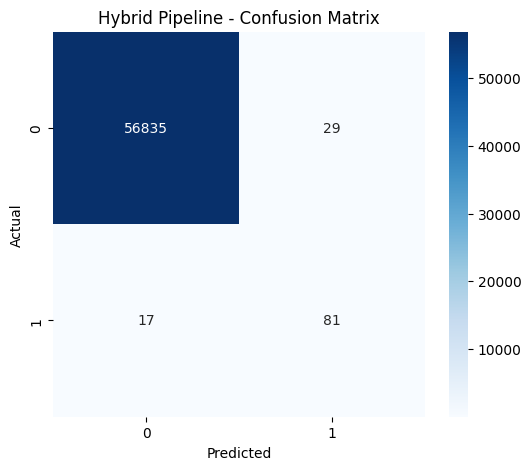

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Hybrid Pipeline - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [15]:
roc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", roc)

ROC-AUC: 0.9745033441767252


In [16]:
pipeline.feature_importances().head(10)

V14       0.508752
V4        0.062700
V12       0.041189
V8        0.028679
V20       0.024987
V28       0.021507
Amount    0.020048
V13       0.019732
V27       0.018871
V22       0.017661
dtype: float32

In [17]:
import joblib

joblib.dump(pipeline, "../models/hybrid_pipeline.pkl")
print("Pipeline guardado correctamente")

Pipeline guardado correctamente


In [18]:
fraud_sample = df[df["Class"] == 1].drop("Class", axis=1).iloc[0].to_dict()
fraud_sample

{'Time': 406.0,
 'V1': -2.3122265423263,
 'V2': 1.95199201064158,
 'V3': -1.60985073229769,
 'V4': 3.9979055875468,
 'V5': -0.522187864667764,
 'V6': -1.42654531920595,
 'V7': -2.53738730624579,
 'V8': 1.39165724829804,
 'V9': -2.77008927719433,
 'V10': -2.77227214465915,
 'V11': 3.20203320709635,
 'V12': -2.89990738849473,
 'V13': -0.595221881324605,
 'V14': -4.28925378244217,
 'V15': 0.389724120274487,
 'V16': -1.14074717980657,
 'V17': -2.83005567450437,
 'V18': -0.0168224681808257,
 'V19': 0.416955705037907,
 'V20': 0.126910559061474,
 'V21': 0.517232370861764,
 'V22': -0.0350493686052974,
 'V23': -0.465211076182388,
 'V24': 0.320198198514526,
 'V25': 0.0445191674731724,
 'V26': 0.177839798284401,
 'V27': 0.261145002567677,
 'V28': -0.143275874698919,
 'Amount': 0.0}

In [19]:
normal_sample = df[df["Class"] == 0].drop("Class", axis=1).iloc[0].to_dict()
normal_sample

{'Time': 0.0,
 'V1': -1.3598071336738,
 'V2': -0.0727811733098497,
 'V3': 2.53634673796914,
 'V4': 1.37815522427443,
 'V5': -0.338320769942518,
 'V6': 0.462387777762292,
 'V7': 0.239598554061257,
 'V8': 0.0986979012610507,
 'V9': 0.363786969611213,
 'V10': 0.0907941719789316,
 'V11': -0.551599533260813,
 'V12': -0.617800855762348,
 'V13': -0.991389847235408,
 'V14': -0.311169353699879,
 'V15': 1.46817697209427,
 'V16': -0.470400525259478,
 'V17': 0.207971241929242,
 'V18': 0.0257905801985591,
 'V19': 0.403992960255733,
 'V20': 0.251412098239705,
 'V21': -0.018306777944153,
 'V22': 0.277837575558899,
 'V23': -0.110473910188767,
 'V24': 0.0669280749146731,
 'V25': 0.128539358273528,
 'V26': -0.189114843888824,
 'V27': 0.133558376740387,
 'V28': -0.0210530534538215,
 'Amount': 149.62}